In [3]:
import pandas as pd

data = {
    "Date": [
        "2023-01-01","2023-01-02","2023-01-03",
        "2023-01-04","2023-01-05","2023-01-06",
        "2023-01-07","2023-01-08","2023-01-09",
        "2023-01-10","2023-01-11","2023-01-12",
        "2023-01-13","2023-01-14","2023-01-15"
    ],

    "Sales": [
        200,210,250,230,260,
        270,300,320,310,330,
        350,370,360,390,400
    ]
}

df = pd.DataFrame(data)

df.to_csv("sales.csv", index=False)

print("sales.csv file created successfully!")


sales.csv file created successfully!


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


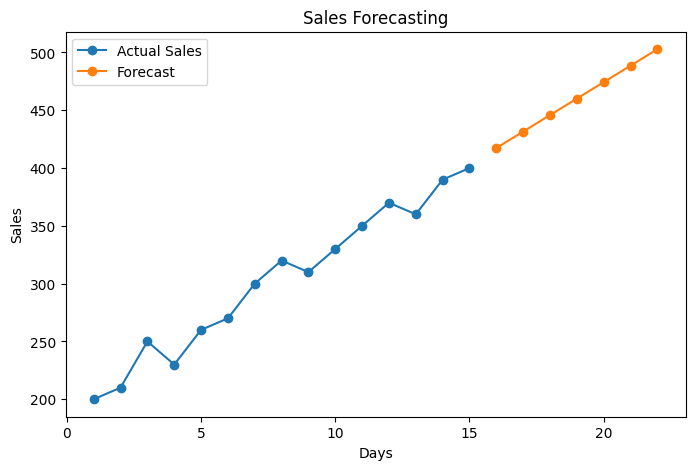

Mean Absolute Error: 8.033333333333333

Next 7 Days Forecast:
Day 16: 417.33
Day 17: 431.58
Day 18: 445.83
Day 19: 460.08
Day 20: 474.33
Day 21: 488.58
Day 22: 502.83


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error

# Load dataset
df = pd.read_csv("sales.csv")

# Convert date column
df['Date'] = pd.to_datetime(df['Date'])

# Create day column
df['Day'] = range(1, len(df)+1)

# Features and target
X = df[['Day']]
y = df['Sales']

# Train model
model = LinearRegression()
model.fit(X, y)

# Predict existing values
predictions = model.predict(X)

# Future prediction
future_days = np.array(range(len(df)+1, len(df)+8)).reshape(-1,1)
future_forecast = model.predict(future_days)

# Plot graph
plt.figure(figsize=(8,5))
plt.plot(df['Day'], y, marker='o', label='Actual Sales')
plt.plot(range(len(df)+1, len(df)+8), future_forecast, marker='o', label='Forecast')

plt.xlabel("Days")
plt.ylabel("Sales")
plt.title("Sales Forecasting")
plt.legend()
plt.show()

# Error
mae = mean_absolute_error(y, predictions)

print("Mean Absolute Error:", mae)

# Forecast output
print("\nNext 7 Days Forecast:")

for i, value in enumerate(future_forecast, start=1):
    print(f"Day {len(df)+i}: {value:.2f}")